In [1]:
import sys
import torch

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Python: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
Torch: 2.9.0+cu130
CUDA: True
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import lzma
from pathlib import Path
from tqdm import tqdm

In [3]:
DATA_PATH = Path("../data/raw/fa.txt.xz")

In [4]:
with lzma.open(DATA_PATH, "rt", encoding="utf-8") as f:
    for _ in range(10):
        print(f.readline())

آشپزخانه کوچک من: February 2012

آشپزخانه کوچک من

بکینگ پودر:2 قاشق چای خوری

تخم مرغ:2 عدد بزرگ

کره:225 گرم به دمای اتاق رسیده

شکر:1و1/2 پیمانه+ 3 قاشق غذا خوری

پودر دارچین:2 و1/2قاشق چای خوری

فر رو روی 350 درجه فارنهایت روشن کنید

کره رو با شکر هم بزنید تا یکدست و کرمی بشه تخم مرغها رو دونه دونه اضافه کنید و هم بزنید

ارد و بکینگ پودر و نمک رو الک کنید و اضافه کنید



In [6]:
line_count = 0

with lzma.open(DATA_PATH, "rt", encoding="utf-8") as f:
    for _ in tqdm(f):
        line_count += 1

print(line_count)

611039245it [21:16, 478833.70it/s]

611039245


In [11]:
lengths = []

with lzma.open(DATA_PATH, "rt", encoding="utf-8") as f:

    for i, line in enumerate(f):

        lengths.append(len(line))

        if i == 50000:
            break

print('min: ',min(lengths))
print('max: ',max(lengths))
print('sum: ',sum(lengths)/len(lengths))

min:  1
max:  2213
sum:  108.01259974800504


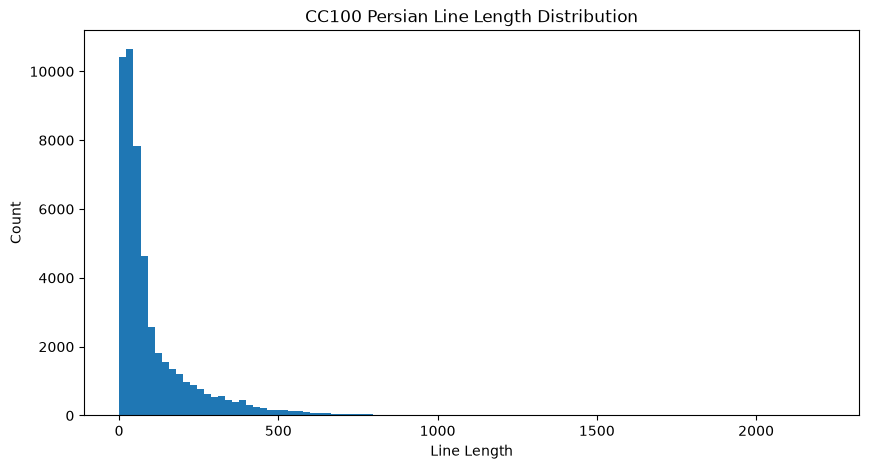

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=100)
plt.xlabel("Line Length")
plt.ylabel("Count")
plt.title("CC100 Persian Line Length Distribution")
plt.show()